In [ ]:
import os
import json
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import Dataset, DataLoader

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
BASE_PATH = "/content/drive/MyDrive/Underwater-Image-Data-set-main"

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
config_path = os.path.join(
    BASE_PATH,
    "Day19_Configuration.json"
)

with open(config_path, "r") as f:
    day19_config = json.load(f)

print("========== DAY 19 CONFIGURATION ==========")

for key, value in day19_config.items():
    print(f"{key}: {value}")

========== DAY 19 CONFIGURATION ==========
model: U-Net
dataset: Dataset V1
loss_function: L1Loss
optimizer: Adam
epochs: 5
selected_learning_rate: 0.0001
selected_validation_loss: 0.1759122337984002


In [ ]:
split_file = os.path.join(
    BASE_PATH,
    "Dataset_V1_frozen_split.json"
)

with open(split_file, "r") as f:
    split_data = json.load(f)

train_pairs = [
    tuple(x) for x in split_data["train"]
]

val_pairs = [
    tuple(x) for x in split_data["validation"]
]

test_pairs = [
    tuple(x) for x in split_data["test"]
]

print("Training pairs   :", len(train_pairs))
print("Validation pairs :", len(val_pairs))
print("Testing pairs    :", len(test_pairs))

Training pairs   : 863
Validation pairs : 184
Testing pairs    : 186


In [ ]:
class UnderwaterDataset(Dataset):

    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):

        input_path, target_path = self.pairs[index]

        input_image = Image.open(
            input_path
        ).convert("RGB")

        target_image = Image.open(
            target_path
        ).convert("RGB")

        input_image = input_image.resize(
            (256, 256)
        )

        target_image = target_image.resize(
            (256, 256)
        )

        input_image = (
            np.array(input_image)
            .astype(np.float32) / 255.0
        )

        target_image = (
            np.array(target_image)
            .astype(np.float32) / 255.0
        )

        input_image = torch.tensor(
            input_image
        ).permute(2, 0, 1)

        target_image = torch.tensor(
            target_image
        ).permute(2, 0, 1)

        return input_image, target_image

In [ ]:
val_dataset = UnderwaterDataset(
    val_pairs
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)

print(
    "Validation samples:",
    len(val_dataset)
)

Validation samples: 184


In [ ]:
class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                3,
                padding=1
            ),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)


class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.down1 = DoubleConv(3, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.middle = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(
            256,
            128,
            2,
            stride=2
        )

        self.conv3 = DoubleConv(
            256,
            128
        )

        self.up2 = nn.ConvTranspose2d(
            128,
            64,
            2,
            stride=2
        )

        self.conv2 = DoubleConv(
            128,
            64
        )

        self.up1 = nn.ConvTranspose2d(
            64,
            32,
            2,
            stride=2
        )

        self.conv1 = DoubleConv(
            64,
            32
        )

        self.final = nn.Conv2d(
            32,
            3,
            1
        )

    def forward(self, x):

        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        d3 = self.down3(p2)
        p3 = self.pool3(d3)

        m = self.middle(p3)

        u3 = self.up3(m)

        u3 = torch.cat(
            [u3, d3],
            dim=1
        )

        u3 = self.conv3(u3)

        u2 = self.up2(u3)

        u2 = torch.cat(
            [u2, d2],
            dim=1
        )

        u2 = self.conv2(u2)

        u1 = self.up1(u2)

        u1 = torch.cat(
            [u1, d1],
            dim=1
        )

        u1 = self.conv1(u1)

        return torch.sigmoid(
            self.final(u1)
        )

In [ ]:
model_path = os.path.join(
    BASE_PATH,
    "Day17_Results",
    "best_unet_model.pth"
)

best_model = UNet().to(device)

best_model.load_state_dict(
    torch.load(
        model_path,
        map_location=device
    )
)

best_model.eval()

print("Best U-Net loaded successfully.")
print("Model path:")
print(model_path)

Best U-Net loaded successfully.
Model path:
/content/drive/MyDrive/Underwater-Image-Data-set-main/Day17_Results/best_unet_model.pth


In [ ]:
all_inputs = []
all_targets = []
all_outputs = []

with torch.no_grad():

    for inputs, targets in val_loader:

        inputs_gpu = inputs.to(device)

        outputs = best_model(
            inputs_gpu
        )

        all_inputs.append(
            inputs.cpu()
        )

        all_targets.append(
            targets.cpu()
        )

        all_outputs.append(
            outputs.cpu()
        )

all_inputs = torch.cat(
    all_inputs
)

all_targets = torch.cat(
    all_targets
)

all_outputs = torch.cat(
    all_outputs
)

print("Inputs :", all_inputs.shape)
print("Outputs:", all_outputs.shape)
print("Targets:", all_targets.shape)

Inputs : torch.Size([184, 3, 256, 256])
Outputs: torch.Size([184, 3, 256, 256])
Targets: torch.Size([184, 3, 256, 256])


In [ ]:
image_errors = []

for i in range(
    len(all_inputs)
):

    error = torch.mean(
        torch.abs(
            all_outputs[i]
            -
            all_targets[i]
        )
    ).item()

    image_errors.append(error)

image_errors = np.array(
    image_errors
)

print(
    "Mean validation L1:",
    image_errors.mean()
)

print(
    "Minimum error:",
    image_errors.min()
)

print(
    "Maximum error:",
    image_errors.max()
)

Mean validation L1: 0.17591222914178734
Minimum error: 0.06850510835647583
Maximum error: 0.4342045783996582


In [ ]:
best_indices = np.argsort(
    image_errors
)[:3]

worst_indices = np.argsort(
    image_errors
)[-3:][::-1]

print("========== SUCCESSFUL CASES ==========")

for idx in best_indices:

    print(
        f"Image {idx} | "
        f"L1 Error = {image_errors[idx]:.6f}"
    )

print()

print("========== DIFFICULT / FAILURE CASES ==========")

for idx in worst_indices:

    print(
        f"Image {idx} | "
        f"L1 Error = {image_errors[idx]:.6f}"
    )

========== SUCCESSFUL CASES ==========
Image 28 | L1 Error = 0.068505
Image 69 | L1 Error = 0.072528
Image 57 | L1 Error = 0.081892

========== DIFFICULT / FAILURE CASES ==========
Image 103 | L1 Error = 0.434205
Image 167 | L1 Error = 0.361372
Image 131 | L1 Error = 0.346797


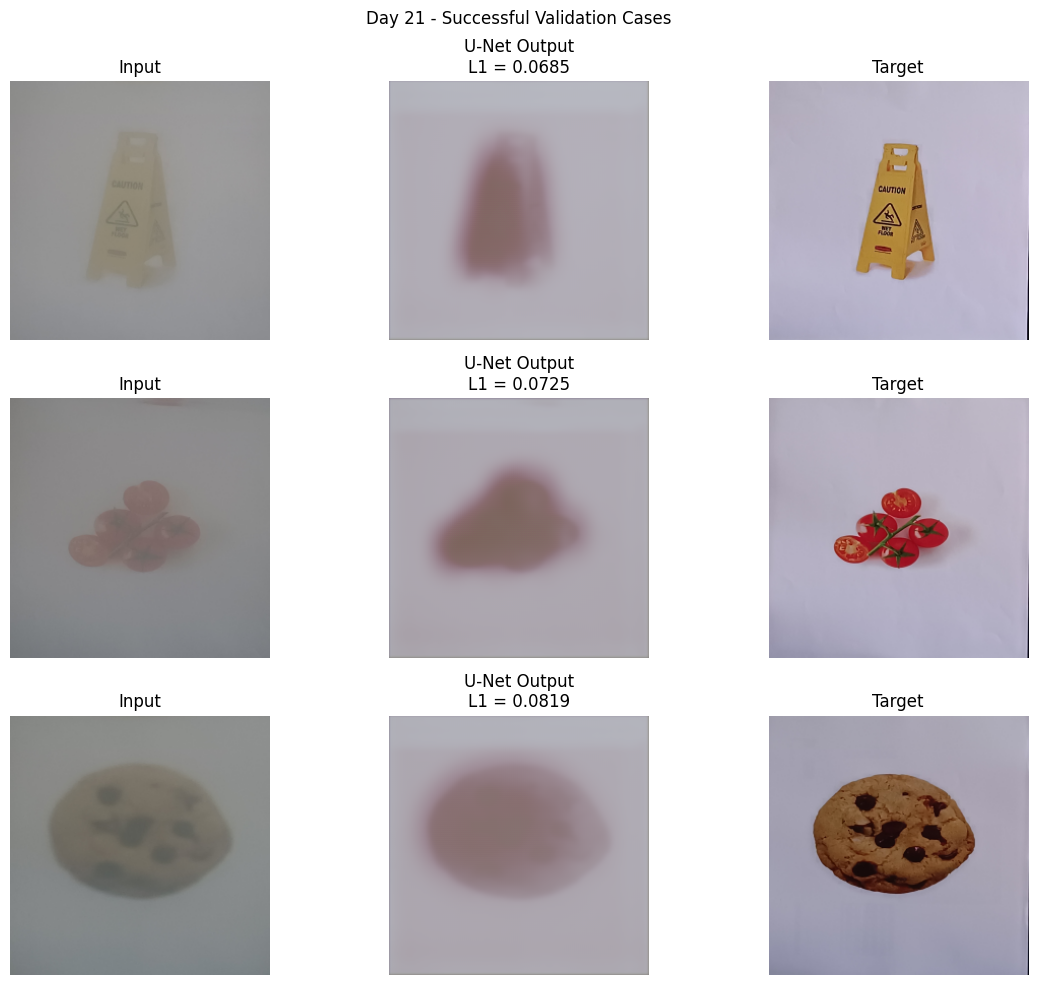

In [ ]:
plt.figure(
    figsize=(12, 10)
)

for row, idx in enumerate(
    best_indices
):

    input_img = (
        all_inputs[idx]
        .permute(1, 2, 0)
        .numpy()
    )

    output_img = (
        all_outputs[idx]
        .permute(1, 2, 0)
        .numpy()
    )

    target_img = (
        all_targets[idx]
        .permute(1, 2, 0)
        .numpy()
    )

    plt.subplot(
        3, 3,
        row * 3 + 1
    )

    plt.imshow(input_img)
    plt.title("Input")
    plt.axis("off")

    plt.subplot(
        3, 3,
        row * 3 + 2
    )

    plt.imshow(output_img)

    plt.title(
        f"U-Net Output\n"
        f"L1 = {image_errors[idx]:.4f}"
    )

    plt.axis("off")

    plt.subplot(
        3, 3,
        row * 3 + 3
    )

    plt.imshow(target_img)
    plt.title("Target")
    plt.axis("off")

plt.suptitle(
    "Day 21 - Successful Validation Cases"
)

plt.tight_layout()
plt.show()

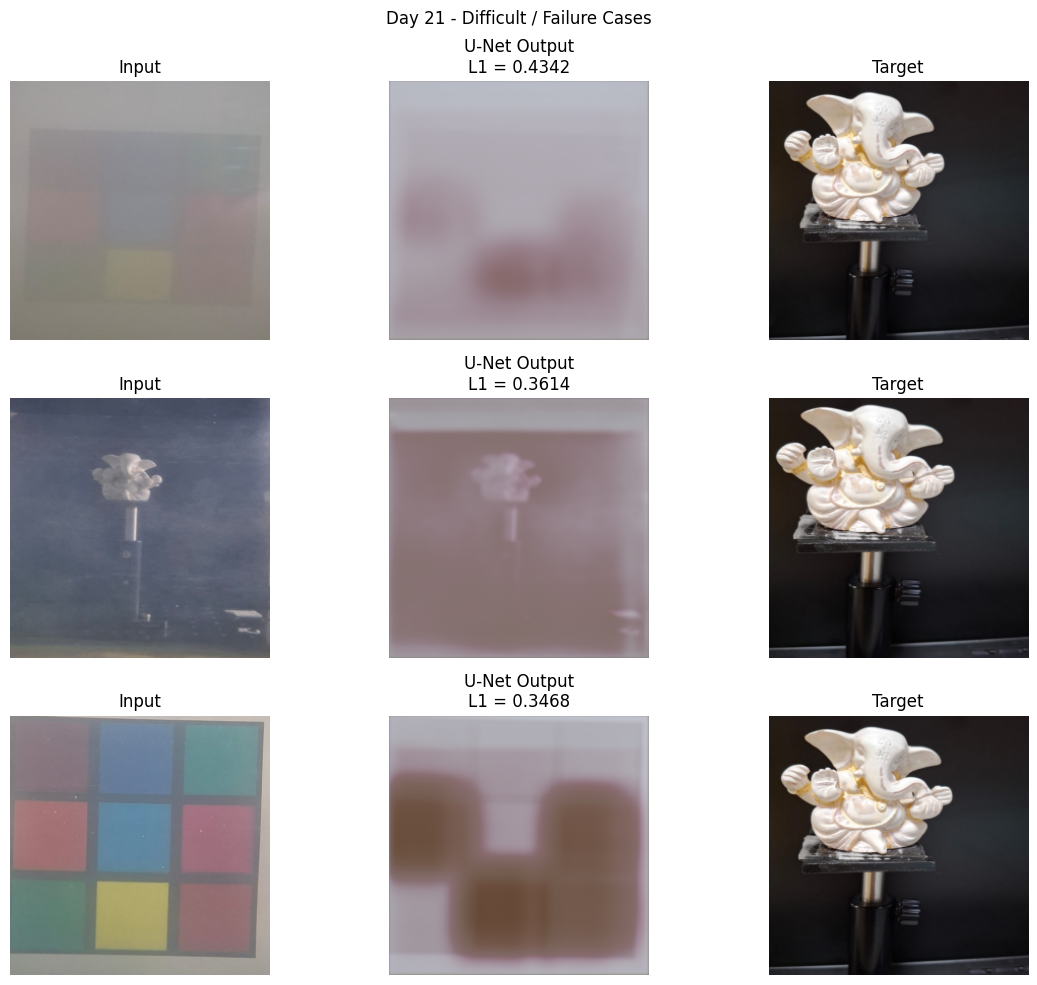

In [ ]:
plt.figure(
    figsize=(12, 10)
)

for row, idx in enumerate(
    worst_indices
):

    input_img = (
        all_inputs[idx]
        .permute(1, 2, 0)
        .numpy()
    )

    output_img = (
        all_outputs[idx]
        .permute(1, 2, 0)
        .numpy()
    )

    target_img = (
        all_targets[idx]
        .permute(1, 2, 0)
        .numpy()
    )

    plt.subplot(
        3, 3,
        row * 3 + 1
    )

    plt.imshow(input_img)
    plt.title("Input")
    plt.axis("off")

    plt.subplot(
        3, 3,
        row * 3 + 2
    )

    plt.imshow(output_img)

    plt.title(
        f"U-Net Output\n"
        f"L1 = {image_errors[idx]:.4f}"
    )

    plt.axis("off")

    plt.subplot(
        3, 3,
        row * 3 + 3
    )

    plt.imshow(target_img)
    plt.title("Target")
    plt.axis("off")

plt.suptitle(
    "Day 21 - Difficult / Failure Cases"
)

plt.tight_layout()
plt.show()

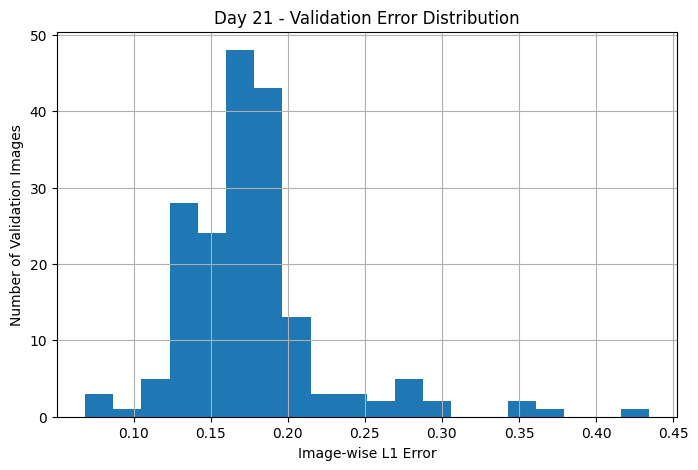

In [ ]:
plt.figure(
    figsize=(8, 5)
)

plt.hist(
    image_errors,
    bins=20
)

plt.xlabel(
    "Image-wise L1 Error"
)

plt.ylabel(
    "Number of Validation Images"
)

plt.title(
    "Day 21 - Validation Error Distribution"
)

plt.grid()

plt.show()

In [ ]:
day21_summary = {
    "task": "Best Candidate Review",
    "model": "U-Net",
    "dataset": "Dataset V1",
    "selected_learning_rate":
        day19_config["selected_learning_rate"],
    "validation_loss":
        day19_config["selected_validation_loss"],
    "mean_image_wise_L1":
        float(image_errors.mean()),
    "minimum_image_wise_L1":
        float(image_errors.min()),
    "maximum_image_wise_L1":
        float(image_errors.max()),
    "successful_cases":
        best_indices.tolist(),
    "difficult_cases":
        worst_indices.tolist()
}

print(
    json.dumps(
        day21_summary,
        indent=4
    )
)

{
    "task": "Best Candidate Review",
    "model": "U-Net",
    "dataset": "Dataset V1",
    "selected_learning_rate": 0.0001,
    "validation_loss": 0.1759122337984002,
    "mean_image_wise_L1": 0.17591222914178734,
    "minimum_image_wise_L1": 0.06850510835647583,
    "maximum_image_wise_L1": 0.4342045783996582,
    "successful_cases": [
        28,
        69,
        57
    ],
    "difficult_cases": [
        103,
        167,
        131
    ]
}


In [ ]:
day21_folder = os.path.join(
    BASE_PATH,
    "Day21_Results"
)

os.makedirs(
    day21_folder,
    exist_ok=True
)

summary_path = os.path.join(
    day21_folder,
    "Day21_Review.json"
)

with open(
    summary_path,
    "w"
) as f:

    json.dump(
        day21_summary,
        f,
        indent=4
    )

print(
    "Day 21 summary saved:"
)

print(summary_path)

Day 21 summary saved:
/content/drive/MyDrive/Underwater-Image-Data-set-main/Day21_Results/Day21_Review.json
